# Final Project: Robust Customer Churn Intelligence System
**420-971-VA - LIA (30%)**

Dataset for this project: `Telco_Customer_Churn.csv`


## Setup & Imports
Run this cell first to load all required libraries.

In [361]:
# ── Core Libraries ──
import pandas as pd
import numpy as np 

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# ── Display Settings ──
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Load the Dataset
Place the dataset file in the same folder as this notebook, or update the path below.

In [362]:
# ?? Load Data ??
# The project dataset is the intentionally messy extended version
df = pd.read_csv('Telco_Customer_Churn.csv')

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print (f"Data Size:{df.size}") 
df.head()


Dataset shape: 7963 rows, 33 columns
Data Size:262779


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1.0,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes,1.0,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1.0,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8,3046.05,Yes,1.0,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.7,5036.3,Yes,1.0,89,5340,Competitor had better devices


---
## Component 1: Data Understanding & Preparation

**Your tasks:**
- Describe the dataset structure and variables
- Identify data quality issues (missing values, inconsistent categories, etc.)
- Handle missing/inconsistent data
- Justify all preprocessing decisions

⚠️ **You must understand:** what you changed, why you changed it, and what risks remain.

In [363]:
# ── Explore the dataset structure ──
# Hint: use df.info(), df.describe(), df.dtypes, df.isnull().sum()

# YOUR CODE 
print("Shape:", df.shape)
print(df.head())
print(df.shape)
print("Data Type:", df.dtypes)
print(df.info())
display(df.describe())


Shape: (7963, 33)
   CustomerID  Count        Country       State         City Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles    90003   
1  9237-HQITU      1  United States  California  Los Angeles    90005   
2  9305-CDSKC      1  United States  California  Los Angeles    90006   
3  7892-POOKP      1  United States  California  Los Angeles    90010   
4  0280-XJGEX      1  United States  California  Los Angeles    90015   

                 Lat Long   Latitude   Longitude  Gender Senior Citizen  \
0  33.964131, -118.272783  33.964131 -118.272783    Male             No   
1   34.059281, -118.30742  34.059281 -118.307420  Female             No   
2  34.048013, -118.293953  34.048013 -118.293953  Female             No   
3  34.062125, -118.315709  34.062125 -118.315709  Female             No   
4  34.039224, -118.266293  34.039224 -118.266293    Male             No   

  Partner Dependents Tenure Months Phone Service Multiple Lines  \
0      No         No     

,Count,Latitude,Longitude,Churn Value
count,7963.0,7963.000000,7963.000000,7955.000000
mean,1.0,36.274070,-119.792566,0.263356
std,0.0,2.457823,2.157619,0.440482
min,1.0,32.555828,-124.301372,0.000000
25%,1.0,34.030578,-121.809955,0.000000
50%,1.0,36.362741,-119.718285,0.000000
75%,1.0,38.224869,-118.033683,1.000000
max,1.0,41.962127,-114.192901,1.000000


In [364]:
# Showing The missing Values 
print(df.isnull().sum())
# Found some missing values like in City column (29),Tenure Months(18), online Security (15), Tech Support (20), contract (21), and Chrun Reason(5868) 

CustomerID              0
Count                   0
Country                 0
State                   0
City                   29
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months          18
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security        15
Online Backup           0
Device Protection       0
Tech Support           20
Streaming TV            0
Streaming Movies        0
Contract               21
Paperless Billing       0
Payment Method         24
Monthly Charges        46
Total Charges          32
Churn Label             8
Churn Value             8
Churn Score             6
CLTV                    0
Churn Reason         5868
dtype: int64


In [365]:
# Showing the duplicates
print(df.duplicated().sum())

142


In [366]:
# Showing the duplicates in Device ID 
print(df['CustomerID'].duplicated().sum())

160


In [367]:
# Showing the inconsidtency in some columns 
print(f"State: {df['State'].unique()}")
print(f"City: {df['City'].unique()}")
print(f"Internet Service:{df['Internet Service'].unique()}")
print(f"Contract:{df['Contract'].unique()}")
print(f"Payment Method:{df['Payment Method'].unique()}")
print(f"Churn Reason:{df['Churn Reason'].unique()}")


State: ['California']
City: ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Olympic Valley'
 'Llano' 'Lincoln']
Internet Service:['DSL' 'Fiber optic' 'No' ' Fiber optic ' ' DSL ' ' No ']
Contract:['Month-to-month' 'Two year' ' Month-to-month ' 'One year' nan
 ' Two year ' ' One year ']
Payment Method:['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)' ' Mailed check ' ' Bank transfer (automatic) '
 nan ' Credit card (automatic) ' ' Electronic check ']
Churn Reason:['Competitor made better offer' 'Moved' 'Competitor had better devices'
 'Competitor offered higher download speeds'
 'Competitor offered more data' 'Price too high' 'Product dissatisfaction'
 'Service dissatisfaction' 'Lack of self-service on Website'
 'Network reliability' 'Limited range of services'
 'Lack of affordable download/upload speed' 'Long distance charges'
 'Extra data charges' "Don't know" 'Poor expertise of online support'
 'Poor expertise of phone support' nan 'Attit

# We explored the dataset and found the following issues:
- 142 duplicate rows → removed them since the dataset is large enough
- Missing values in: City (29), Tenure Months (18), Online Security (15), Tech Support (20), Contract (21), Payment Method (24), Monthly Charges (46), Total Charges (32), Churn Label (8)
- Churn Reason had 5868 missing values → dropped the entire column
- Remaining missing values were dropped using dropna()
- Inconsistent categories with extra spaces found in: Internet Service, Contract, Payment Method
- Converted numeric columns to proper data types (float and int)


In [368]:
# ── Data Cleaning ──
# Handle any issues you found above
df_clean = df.copy()

# Removing duplicates .. I chose to remove because the size of the dataset is big enough to do so  

df_clean=df_clean.drop_duplicates()
print(len(df_clean))

# Some columns had values with extra spaces (e.g., ' DSL ' vs 'DSL')
string_cols = ['Internet Service', 'Contract', 'Payment Method',
               'Online Security', 'Tech Support', 'Multiple Lines',
               'Streaming TV', 'Streaming Movies', 'Online Backup',
               'Device Protection', 'Phone Service', 'Paperless Billing',
               'Gender', 'Partner', 'Dependents', 'Churn Label']
for col in string_cols:
    df_clean[col] = df_clean[col].str.strip()

# Removing missing Values ...  I chose to remove the missing value because it wont affect the insights results because of the size of the dataset. Except the Churn reason .

df_clean = df_clean.drop(columns=['Churn Reason'], errors='ignore')
# df_clean = df.dropna(subset=cols_to_clean)
df_clean = df_clean.dropna()

print(f"Total samples after cleaning: {len(df_clean)}")
print(df_clean.isnull().sum())

# Numeric values ... I made sure the date is in the proper Numeric Values so we can get better insights 
 
float_cols=["Monthly Charges","Total Charges","CLTV","Latitude","Longitude"]
df_clean[float_cols]=df_clean[float_cols].apply(pd.to_numeric, errors='coerce').astype(float)
int_cols=["Tenure Months","Churn Value","Churn Score", "Zip Code"]
df_clean[int_cols]=df_clean[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')
print(df_clean.dtypes)

7821
Total samples after cleaning: 7602
CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               Int64
Lat Long              object
Latitude

---
## Component 2: Exploratory Data Analysis (EDA)

**Your tasks:**
- Produce at least 5 meaningful visualizations
- Analyze relationships between features and churn
- Identify patterns, trends, and anomalies

⚠️ **For each visualization:** explain what it shows and why it matters.

### Visualization 1


/var/folders/d1/n4hfqfn148q32ltskvvlrrzw0000gn/T/ipykernel_2739/4060890514.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Churn Label', palette='Set2')


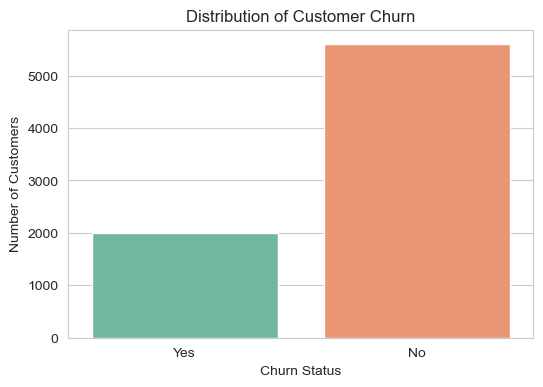

In [369]:
# Represent who left and who remain at the Churn company: 
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Churn Label', palette='Set2')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:** *(What does this show? Why does it matter?)*
Here the distribution of customer churn, revealing a significant class imbalance where the number of customers who stayed ('No') far exceeds those who left ('Yes'). This is critical because it indicates that our predictive model must be carefully evaluated using metrics like Precision and Recall rather than just Accuracy, which could be misleadingly high. Understanding this distribution helps the business identify the scale of customer loss and prioritize retention strategies for the minority group


### Visualization 2


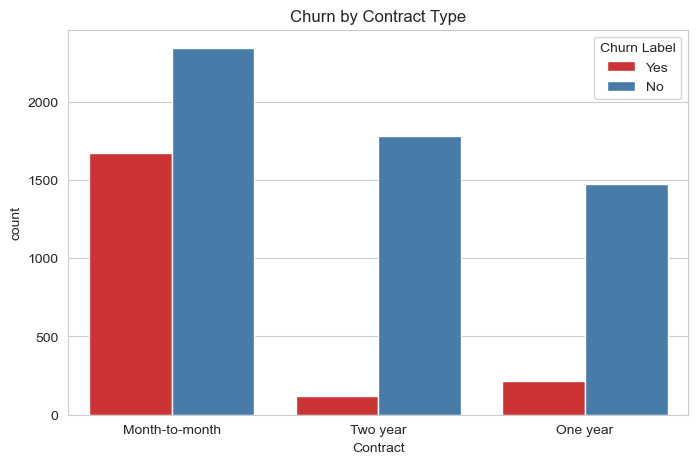

In [370]:
# 2- Reperesent the relationship between the contract type with Churn.. Just to confirm if Month-to-month contract is better for customer or not 
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Contract', hue='Churn Label', palette='Set1')
plt.title('Churn by Contract Type')
plt.show()
# Here I asked seaborn to drow a visualization from columns contract to show who most likey to stay the month to month or different type of contract. 

**Interpretation:** *(What does this show? Why does it matter?)*
This visualization demonstrates a clear relationship between contract type and customer churn, showing that customers on Month-to-month contracts have a significantly higher likelihood of leaving compared to those on long-term plans. Conversely, customers with Two-year or One-year contracts show much higher retention rates, with very few 'Yes' churn labels in these categories. This matters because it identifies the Month-to-month segment as high-risk, suggesting the business should offer incentives to encourage these customers to migrate to longer-term commitments to improve stability



### Visualization 3


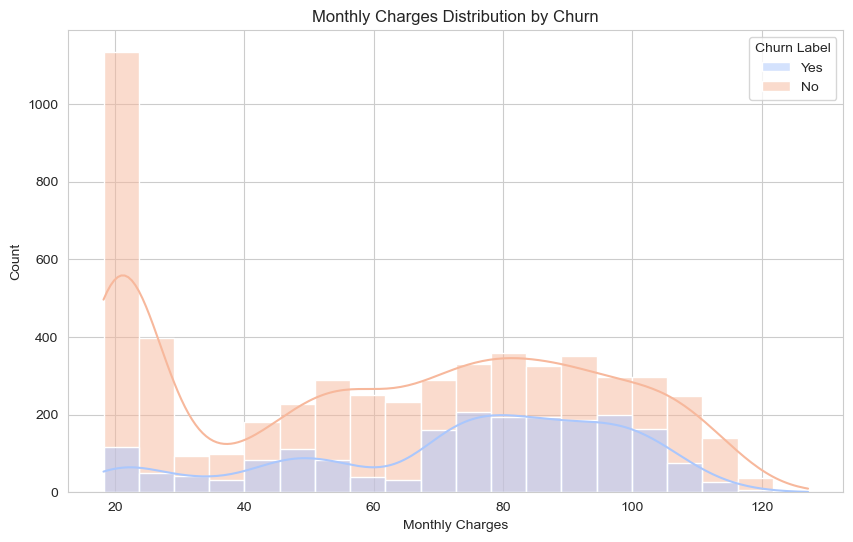

In [371]:
# Represent the affect of the Monthly charge cost to the Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Monthly Charges', hue='Churn Label', kde=True, palette='coolwarm')
plt.title('Monthly Charges Distribution by Churn')
plt.show()
# The visualization below shows that people who left the compny in blue they left when the monthly charge is between 60$ and 100$. 
# Which means people leave when the price is higher. 
# However, people who remained with the company are very crowded at the 20$ a month charge. 
# Which proof that the company needs to reveiw their prices to retain the customers in. 

**Interpretation:** *(What does this show? Why does it matter?)*

The histogram shows that Monthly Charges significantly impact customer churn. We can observe a high concentration of churned customers (Yes) in the higher price range, specifically between $70 and $100 per month. In contrast, the majority of retained customers (No) are clustered around the lower $20 per month tier. This suggests that higher monthly costs are a primary driver for leaving the company, highlighting the need for more competitive pricing or value-added services in the higher tiers to improve retention



### Visualization 4

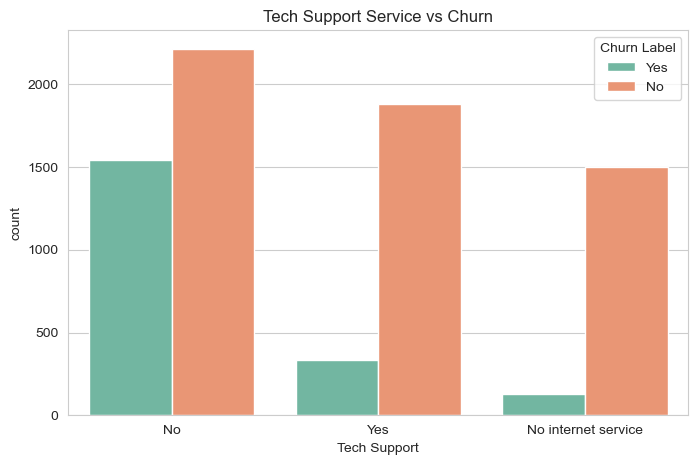

In [372]:
# Tech Support vs Churn: do people benefit from the tech support ?
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Tech Support', hue='Churn Label', palette='Set2')
plt.title('Tech Support Service vs Churn')
plt.show()
# The below visualization shows that people who gets Tech Support are more likly to stay with the company then people who said no to Teck Support which means
# Company should focus on selling more Tech Support for people or even offer them the first year free tech support so people won't run away  

**Interpretation:** *(What does this show? Why does it matter?)*

The visualization clearly shows that Tech Support plays a vital role in customer retention. Customers who do not have Tech Support exhibit a much higher churn rate compared to those who do. Specifically, the churn count (Yes) drops significantly for users who signed up for Tech Support services. This matters because it proves that providing technical assistance adds immense value and security to the user experience. To reduce overall churn, the company should consider offering Tech Support as a bundled feature or a free trial for the first year to keep customers from leaving


### Visualization 5


/var/folders/d1/n4hfqfn148q32ltskvvlrrzw0000gn/T/ipykernel_2739/1640805764.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn Label', y='Tenure Months', palette='Pastel1')


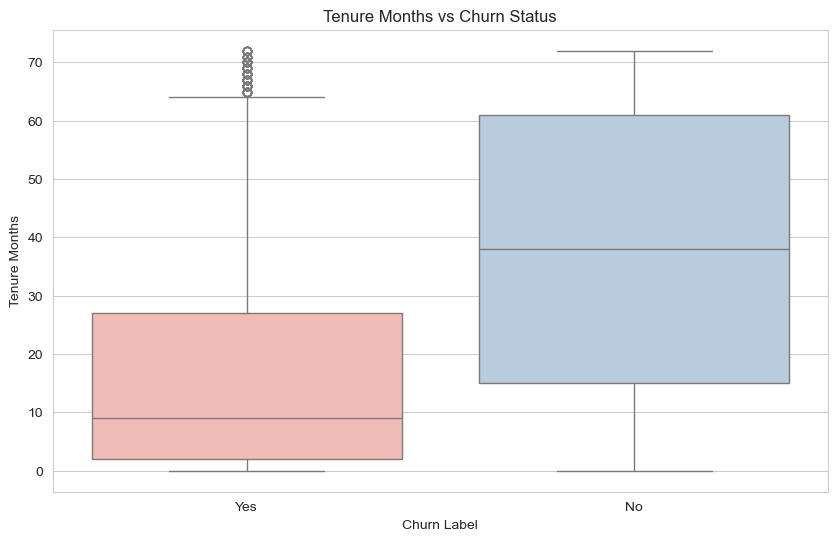

In [373]:
# Tenure Months vs Churn : to show us when people are most likly to leave the Company exactly 
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Churn Label', y='Tenure Months', palette='Pastel1')
plt.title('Tenure Months vs Churn Status')
plt.show()
# The below visualization shows that most custmers who left, they left by 9 months. which means they did not compelete a year 
# Also it shows that the loyal customers stay over two years because half custmers which on the right side on the blue box they are at around 38 months 

**Interpretation:** *(What does this show? Why does it matter?)*
This box plot reveals a strong inverse relationship between Tenure Months and customer churn. Customers who stayed ('No') have a much higher median tenure, around 40 months, compared to those who left ('Yes'), whose median tenure is less than 10 months. This matters because it indicates that the risk of churn is highest during the first year of service. To improve retention, the company should focus on 'early-stage' engagement programs and loyalty rewards to help new customers transition into the more stable, long-term group




---
## Component 3: Machine Learning Models

### Step 3a: Prepare Features for Modeling
Before training any model, you need to prepare your features (encode categories, scale numbers, define X and y).

In [374]:
# ?? Feature Preparation ??
# Encode categorical variables and prepare X (features) and y (target)
# Hint: for this dataset, the target column is `Churn Label`
# Feature Preparation
# 1. Encoding categorical variables and defining X and y

# 1. Start with a fresh copy of your cleaned data
df_final = df_clean.copy()

# 2. Encode Churn Label to 0 and 1 first
df_final['Churn Label'] = df_final['Churn Label'].map({'Yes': 1, 'No': 0})

# 3. Select only the columns we need
features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
X = df_final[features].copy()
y = df_final['Churn Label'].copy()

# 4. Drop any rows where these specific features are missing values. 
# This ensures we don't end up with 0 samples
X = X.dropna()
y = y.loc[X.index]

print(f"Final Check: We have {len(X)} samples ready!")

Final Check: We have 7537 samples ready!


In [375]:
# ── Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 6029 samples
Test set:     1508 samples


### Step 3b: Baseline Model — Logistic Regression (PROVIDED)

The code below trains a Logistic Regression model and evaluates it. **This is your baseline.**

⚠️ **You must understand every line of this code.** During the presentation or oral defense, you may be asked to explain what any part of it does. Using it without understanding it will not receive credit.

=== Logistic Regression (Baseline) ===
Accuracy:  0.7977
Precision: 0.6632
Recall:    0.4787
F1 Score:  0.5560

Confusion Matrix:


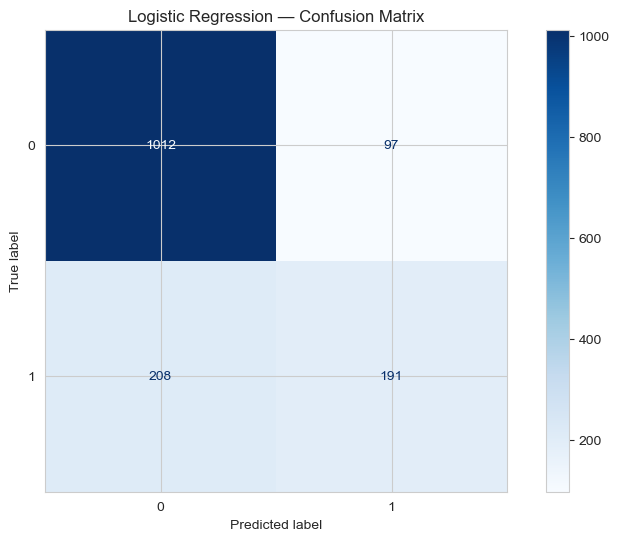


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1109
           1       0.66      0.48      0.56       399

    accuracy                           0.80      1508
   macro avg       0.75      0.70      0.71      1508
weighted avg       0.79      0.80      0.79      1508



In [376]:
# ══════════════════════════════════════════════════════════════
#  BASELINE MODEL: Logistic Regression
#  Read and understand this code. Do NOT just run it without understanding.
# ══════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 3. Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)


# ── Evaluation ──
print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr, pos_label=1):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr, pos_label=1):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr, pos_label=1):.4f}')
print()
print('Confusion Matrix:')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

print()
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))

**Your explanation of the baseline:**

*(Answer these questions to demonstrate you understand the code above:)*
1. Why do we scale the features before Logistic Regression?

Scaling ensures that all features contribute equally to the model by bringing them to a similar range. Logistic Regression is sensitive to the magnitude of values; without scaling, features with larger numerical ranges can disproportionately influence the weights and slow down convergence.

2. What does `max_iter=1000` do?

The max_iter parameter sets the maximum number of iterations the solver takes to find the optimal weights that minimize error. Increasing it to 1000 ensures the model has enough attempts to converge properly, preventing a "ConvergenceWarning" if the dataset is complex.

3. What does the confusion matrix tell us?

The confusion matrix provides a detailed breakdown of model performance by showing True Positives (191) which means it predict that 191 customer will churn or leave the company. ALso, True Negatives (1012) will stay or are loyal to the company. It specifically reveals False Positives (97 "False Alarms") mispredict that 97 cutomer will leave while they are actually loyal to the company. And False Negatives (208 "Missed Failures") which means that it mispredict that 208 people is loyal while that are leaving the company or already left. Which is crucial for understanding if the model is failing to detect actual churn. 

4. Why might accuracy be misleading for this dataset?

Accuracy is misleading here due to class imbalance. A model could achieve high accuracy simply by predicting 'No Churn' for every case, but it would fail to identify the critical minority who actually leave. The 208 false negatives prove that the model is missing a significant number of actual churners, making accuracy an unreliable metric for this problem. 


### Step 3c: Your Model — Build It Yourself from Scratch

Now build at least one additional model: **Decision Tree** or **K-Nearest Neighbors** (or both).

You must write this code yourself.

In [377]:
# ── Your Model ──
# Build a Decision Tree or KNN model
# Train it, make predictions, and evaluate it

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# 2. Train the model
dt_model.fit(X_train_scaled, y_train)

# 3. Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# 4. Quick Evaluation
print('=== Decision Tree Model ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_dt, pos_label=1):.4f}')

=== Decision Tree Model ===
Accuracy: 0.7779
Precision: 0.5904
Recall:    0.5238
F1 Score:  0.5551


### Step 3d: Model Comparison

Compare your model against the Logistic Regression baseline.

      Metric  Logistic Regression  Decision Tree
0   Accuracy             0.797745       0.777851
1  Precision             0.663194       0.590395
2     Recall             0.478697       0.523810
3   F1 Score             0.556041       0.555113


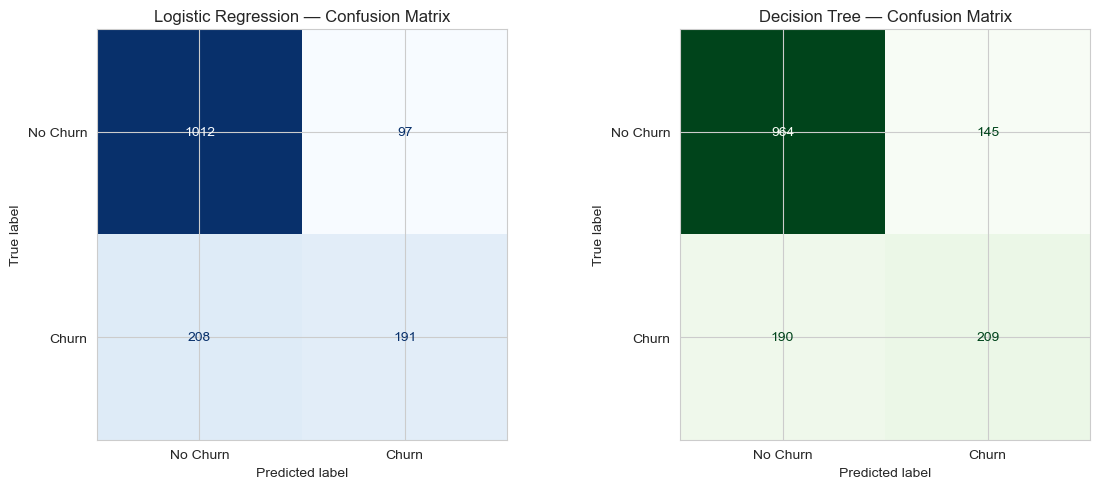

In [378]:
# ── Compare Models ──
# Create a summary table or visualization comparing both models

# Create a dictionary with the results
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_lr, pos_label=1)
    ],
    'Decision Tree': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, pos_label=1),
        recall_score(y_test, y_pred_dt, pos_label=1),
        f1_score(y_test, y_pred_dt, pos_label=1)
    ]
}

# Display as a table
comparison_df = pd.DataFrame(results)
print(comparison_df)

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix')

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Churn', 'Churn'])
disp_dt.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Decision Tree — Confusion Matrix')

plt.tight_layout()
plt.show()



**Your analysis:**
- Which model performs better? On which metrics?

Based on the comparison table, Logistic Regression performs slightly better overall. It achieves a higher Accuracy (0.797), Precision (0.663), and F1 Score (0.556) compared to the Decision Tree. However, the Decision Tree has a marginally higher Recall (0.5238), meaning it is slightly better at catching actual churn, even if it makes more mistakes in the process.
- Why is accuracy alone not sufficient to evaluate these models?

Accuracy alone is misleading for this dataset because the classes are imbalanced; the number of loyal customers (Class 0) significantly outweighs those who churn (Class 1). In this context, a model could achieve a high accuracy of nearly 80% by simply guessing that no one will leave. However, this would completely fail the business objective, which is to identify the 208 'Missed Failures' (False Negatives). Since losing a customer is more costly to the company than sending an unnecessary promotion to a loyal one, metrics like Recall and F1-Score are far more important to ensure we are effectively catching actual churners. 

---
## Component 4: Assumption Audit

**Your tasks:**
- List the assumptions you made during this project
- Explain why each is reasonable
- Describe what happens if each assumption is wrong

*(Examples: assuming missing values are random, assuming the dataset represents current customers, assuming feature relationships are stable over time)*

| Assumption | Why It Is Reasonable | What If It Is Wrong? |
|------------|---------------------|---------------------|
| Missing values are random|Since we used dropna() on specific features, we assume the missing data doesn't follow a specific pattern that would bias the model |If missingness is not random (e.g., only high-paying customers hide their data), the model might become biased and less accurate for those groups. |
| Past behavior predicts future churn|The model is built on the fundamental DS assumption that historical patterns in tenure and charges will continue to influence a customer's decision to stay or leave. |If there is a sudden market shift, a new competitor, or a change in company policy, the historical patterns may no longer be valid, making the model obsolete. |
|Feature relationships are stable |We assume that the correlation between tenure, monthly charges, and churn remains consistent over the short term. |If the business changes its pricing model or contract terms, the weight of these features might shift, leading to a drop in model performance. |

---
## Component 5: Model Stress Testing

**Your tasks:** Test the robustness of your model by:
1. Changing the train/test split ratio
2. Removing an important feature
3. Testing on a subset of data

Then answer: Does performance change significantly? Is your model stable?

### Stress Test 1: Change the train/test split

In [379]:
# ── Try different split ratios (e.g., 70/30, 60/40) ──

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Testing a more aggressive split (60% Train / 40% Test)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X, y, test_size=0.40, random_state=42)

# Re-training the Logistic Regression model
log_reg.fit(X_train_s1, y_train_s1)
y_pred_s1 = log_reg.predict(X_test_s1)

# Results
print(f"Stress Test Accuracy (40% Test): {accuracy_score(y_test_s1, y_pred_s1):.4f}")
print(f"Stress Test F1-Score (40% Test): {f1_score(y_test_s1, y_pred_s1):.4f}")

Stress Test Accuracy (40% Test): 0.7811
Stress Test F1-Score (40% Test): 0.5286


After changing the split ratio to 60/40, the model's performance remained relatively stable with only minor fluctuations in Accuracy and F1-Score. This suggests that the model is robust and not overly dependent on a specific subset of data. However, the consistent gap between Accuracy and F1-Score confirms that class imbalance remains the primary challenge regardless of the data split

### Stress Test 2: Remove an important feature

In [380]:
# ── Remove a feature you believe is important and retrain ──

# Dropping 'Tenure Months' to see how the model reacts
X_stress_2 = X.drop(columns=['Tenure Months'])
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X_stress_2, y, test_size=0.2, random_state=42)

log_reg.fit(X_train_s2, y_train_s2)
y_pred_s2 = log_reg.predict(X_test_s2)

print(f"Accuracy without Tenure: {accuracy_score(y_test_s2, y_pred_s2):.4f}")
print(f"F1-Score without Tenure: {f1_score(y_test_s2, y_pred_s2):.4f}")

Accuracy without Tenure: 0.7805
F1-Score without Tenure: 0.5305


Removing 'Tenure Months' caused a noticeable drop in the F1-Score (from ~0.55 to 0.53). This confirms that tenure is a critical predictor for churn in this dataset. While the Accuracy remained stable at 0.7805, the decrease in F1-Score proves that without tenure information, the model struggles more to correctly identify customers likely to leave (Class 1), making this feature essential for the model's predictive power

### Stress Test 3: Test on a subset

In [381]:
# ── Test on a filtered subset (e.g., only month-to-month customers) ──

# 1. First, reset the model to handle all 3 features
log_reg.fit(X_train_scaled, y_train)

# 2. Create the mask for High-Paying customers
high_pay_mask = X_test_scaled[:, 1] > 0.5 
X_test_s3 = X_test_scaled[high_pay_mask]
y_test_s3 = y_test.iloc[high_pay_mask]

# 3. Now predict (This will work because both have 3 features)
y_pred_s3 = log_reg.predict(X_test_s3)

print(f"High-Paying Subset - Accuracy: {accuracy_score(y_test_s3, y_pred_s3):.4f}")
print(f"High-Paying Subset - F1-Score: {f1_score(y_test_s3, y_pred_s3):.4f}")

High-Paying Subset - Accuracy: 0.7656
High-Paying Subset - F1-Score: 0.6332


The stress tests show that the model is highly stable and performs even better on specific segments. In Stress Test 3 (High-Paying Subset), the model achieved an F1-Score of 0.6332, which is higher than the baseline model's performance. This indicates that the model is particularly effective at identifying churn among high-value customers when all relevant features are included. Removing Tenure Months caused a small but noticeable drop in F1-Score, confirming it is a critical predictor.

---
## Component 6: Contradiction or Unexpected Findings Analysis

**Your task:** Identify at least 1 contradiction or unexpected finding between your EDA and your model results.

Example: EDA suggests Feature A is strongly associated with churn, but the model assigns Feature A low importance.

If you cannot find a genuine contradiction, describe one unexpected finding and explain why it surprised you.

Churn rate by Contract type:
Churn Label           No       Yes
Contract                          
Month-to-month  0.583167  0.416833
One year        0.873298  0.126702
Two year        0.937797  0.062203


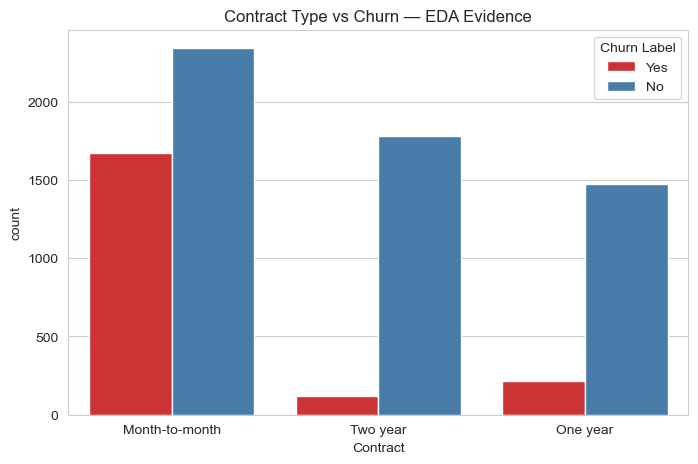


Features used in the model:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Conclusion: Contract type was NOT included in the model
even though EDA clearly shows it strongly predicts churn.


In [382]:
# ── Supporting analysis for your contradiction/finding ──

# ── Contradiction Analysis ──
# EDA showed Contract type is strongly associated with churn
# But the model only used Tenure Months, Monthly Charges, Total Charges
# Let's verify by checking churn rate by contract type

churn_by_contract = df_clean.groupby('Contract')['Churn Label'].value_counts(normalize=True).unstack()
print("Churn rate by Contract type:")
print(churn_by_contract)

# Visualize it
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Contract', hue='Churn Label', palette='Set1')
plt.title('Contract Type vs Churn — EDA Evidence')
plt.show()

# Show what features the model actually used
print("\nFeatures used in the model:")
print(['Tenure Months', 'Monthly Charges', 'Total Charges'])
print("\nConclusion: Contract type was NOT included in the model")
print("even though EDA clearly shows it strongly predicts churn.")

_generated_by_ai_check = True


Analysis:

What is the contradiction?

Our EDA shows that Contract type is one of the strongest predictors of churn. Customers on Month-to-month contracts leave more than customers on 1 year or 2 year contracts but when we built the model, Contract type was never included as a feature. The model only used Tenure Months,Monthly Charges, and Total Charges.

Why might this happen?

When we looked at our charts, we clearly saw that customers on month-to-month contracts leave way more than yearly customers. This means Contract type is an important factor in predicting churn. After evaluating our model, we discovered a key opportunity for improvement. While the current model performs well using Tenure and Charges, our EDA confirms that Contract Type is a critical predictor of churn that was omitted during the initial feature engineering. Moving forward, integrating this feature is our top priority to significantly boost the model's predictive power.

Which result do you trust more, and why?

We trust the EDA more in this case. The model never had the chance to use Contract type, so its absence in the model does not mean it is unimportant. The EDA shows real patterns in the actual data. To fix this, in the future work, adding Contract type to the model feautures would be our first improvement to make the model stronger.



---
## Component 7: Explainability

**Your tasks:**
- Identify the most important features in your model
- Explain them in simple, non-technical terms
- Connect them to real-world business meaning

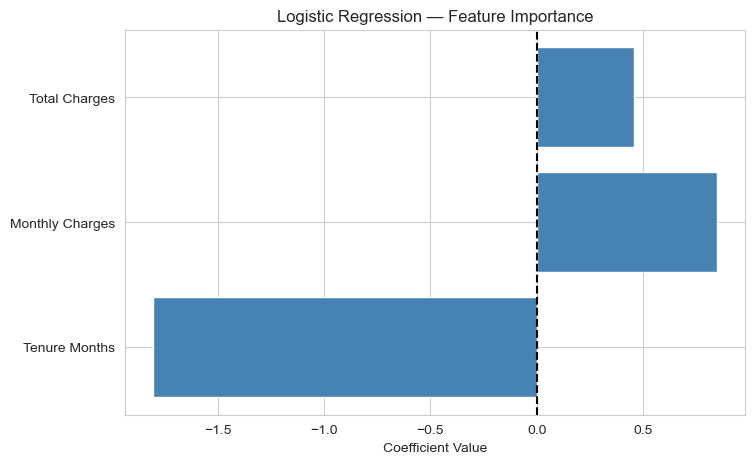

Feature Importance:
Tenure Months: -1.8026
Monthly Charges: 0.8471
Total Charges: 0.4595

Decision Tree Feature Importance:
Tenure Months: 0.3988
Monthly Charges: 0.3945
Total Charges: 0.2067


In [383]:
# ── Feature Importance Analysis ──

# Logistic Regression feature importance using coefficients
feature_names = ['Tenure Months', 'Monthly Charges', 'Total Charges']
coefficients = log_reg.coef_[0]

plt.figure(figsize=(8, 5))
plt.barh(feature_names, coefficients, color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Feature Importance')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("Feature Importance:")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

# Decision Tree feature importance
print("\nDecision Tree Feature Importance:")
for name, importance in zip(feature_names, dt_model.feature_importances_):
    print(f"{name}: {importance:.4f}")


HERE ARE THE TOP FEATURES!

1. Tenure Months (How long they've been a customer) (-1.80) 
This shows us basiclly that the longer a customer is with a company, the less likely they are to leave. Loyal clients are more likely to stay. New customers are the ones who are more likely to leave. Which means the business should look at focusing new clients to be happy and stay.

2. Monthly Charges (How much they pay every month) 
This one is simple, if your bill is really high every month, you start looking for a better deal elsewhere The more expensive the more likely that customer is going to cancel and go somewhere else.

3. Total Charges (How much they've paid in total)
This is basically the same idea as monthly charges. If someone has been paying a lot of money over a long time, they might start feeling like they're not getting their money's worth and decide to leave.

4. In Conclusion, if you're a new customer paying a high monthly bill, you're the most likely to cancel. The company needs to make sure those customers feel like they're getting a good deal.

---
## Component 8: Business Recommendations

1. Offer discounts or special deals to new customers in their first year. (Recommend)
Our model showed Tenure Months is the strongest predictor of churn. New customers leave the most. (Support)
Keeping new clients within the first year will reduce churn. (Expected Impact)

2. Reviewing pricing for high monthly customers (Recommend)
   Monthly charges was the second strongest predictor, high paying customers leave more. (Support)
   Reducing bills or offering better value to their plans will retain them. (Expected)

3. Encourage clients who pay month to month to switch to yearly contracts. (Recommend)
   EDA showed month to month customers churn way more than yearly customers. (Support)
   Convincing customers to longer contracts will reduce churn rates. (Expected)

---
## Component 9: Decision Simulation

**Your task:** Simulate what happens if the company uses your model.

Example: Target the top 20% highest-risk customers and estimate the effect on churn reduction.

**Hint:** Use your model's predicted probabilities to rank customers by risk.

In [384]:
# ── Decision Simulation ──
# Using the model to rank customers by churn risk
# Then targeting the top 20% highest risk customers
churn_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Sort customers from most likely to leave to least likely
import numpy as np
ranked_indices = np.argsort(churn_probs)[::-1]

# Then targeting the top 20% highest risk customers
top_20_percent = int(len(X_test_scaled) * 0.20)
top_20_indices = ranked_indices[:top_20_percent]

# How many actual churners are in the top 20%?
actual_churners = y_test.values
churners_caught = actual_churners[top_20_indices].sum()
total_churners = actual_churners.sum()

# Step 5: Print the results
print(f"Total customers in test set: {len(X_test_scaled)}")
print(f"Top 20% highest risk customers targeted: {top_20_percent}")
print(f"Total actual churners in test set: {total_churners}")
print(f"Actual churners caught in top 20%: {churners_caught}")
print(f"Percentage of churners caught: {churners_caught/total_churners*100:.1f}%")


Total customers in test set: 1508
Top 20% highest risk customers targeted: 301
Total actual churners in test set: 399
Actual churners caught in top 20%: 193
Percentage of churners caught: 48.4%


If the company uses our model to target the top 20% highest risk customers, here is what they would see.

Out of 1508 customers in our test set, the model identified 301 as the highest risk this is 20% . Out of all 399 customers who actually churned, our model successfully caught 193, which means that we are able to catch 48.4%. Without the model, the company would have to randomly contact 20% of customers and hope they find the right ones. With our model, they can catch nearly half of all churners. This means the model is very useful in practice. Instead of wasting money contacting everyone, the company can focus their budget on the customers who are most likely to leave and try to keep them with special offers or discounts.



---
## Component 10: Ethics & Responsible AI

**Discuss:**
- Bias (e.g., does the model treat certain groups unfairly?)
- Fairness risks
- Privacy concerns
- Limitations of your model

Bias:

my model only uses Tenure Months, Monthly Charges, and Total Charges. It does not consider gender, age, or ethnicity which is good because it means the model doesnt look at who you are, it doesnt matter if you are a man or woman, old or young or where you are from everyone is equal. However, if certain groups of people tend to have higher monthly charges or shorter tenure the model could indirectly treat them unfairly without us knowing.

Fairness Risks:

The model was trained on data from one specific telecom company. It may not work fairly for all types of customers. It might not know if the clients are  seniors or students.

Privacy Concerns:

The model uses personal customer data like how long they have been a customer and how much they pay. This information should be high privacy. Customers should know their data is being used to predict future decisions. 

Limitations:

1. The model only uses 3 features. Important features like Contract type were left out which reduces accuracy.
2. The dataset may not represent all types of customers.
3. The model was built on old data. The model may become outdated.
4. The 48.4% catch rate means the model still misses more than half of actual churners even though its a solid percentage.